In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json

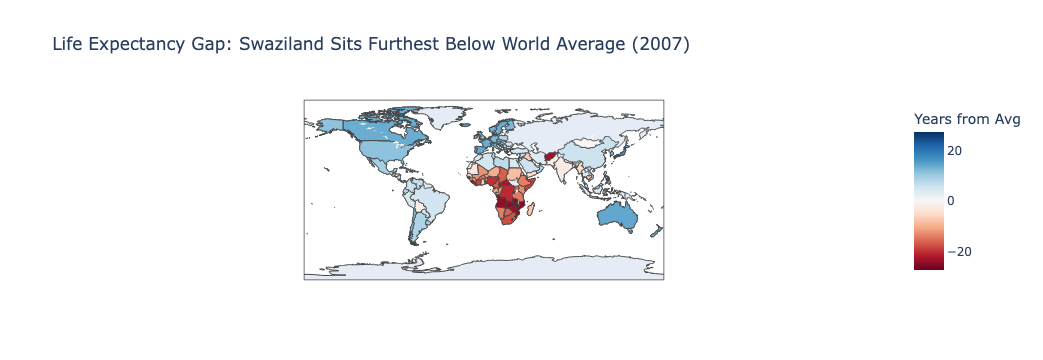

In [2]:
import pandas as pd
import plotly.express as px

# Load Gapminder data
gm = px.data.gapminder()

# Filter for 2007
gm_2007 = gm[gm['year'] == 2007].copy()

# Global average life expectancy
global_avg = gm_2007['lifeExp'].mean()

# Deviation from global average
gm_2007['lifeExp_dev'] = gm_2007['lifeExp'] - global_avg

# Find country furthest below average
lowest_country = gm_2007.loc[
    gm_2007['lifeExp_dev'].idxmin(),
    'country'
]

# Choropleth
fig = px.choropleth(
    gm_2007,
    locations='iso_alpha',
    color='lifeExp_dev',
    hover_name='country',
    hover_data={
        'lifeExp': ':.1f',
        'lifeExp_dev': ':.1f',
        'iso_alpha': False
    },
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    title=f'Life Expectancy Gap: {lowest_country} Sits Furthest Below World Average (2007)'
)

fig.update_layout(
    coloraxis_colorbar_title='Years from Avg'
)

fig.show()

In [3]:
import pandas as pd
import plotly.express as px
import json
import urllib.request

# GeoJSON source
url = "https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/master/2_bundeslaender/4_niedrig.geo.json"

with urllib.request.urlopen(url) as response:
    germany_geojson = json.load(response)

# Inspect properties
print(germany_geojson['features'][0]['properties'])

{'id': 'DE-BW', 'name': 'Baden-Württemberg', 'type': 'State'}


In [4]:
states = pd.DataFrame({
    'state': [
        'Baden-Württemberg',
        'Bayern',
        'Berlin',
        'Brandenburg',
        'Bremen',
        'Hamburg',
        'Hessen',
        'Mecklenburg-Vorpommern',
        'Niedersachsen',
        'Nordrhein-Westfalen',
        'Rheinland-Pfalz',
        'Saarland',
        'Sachsen',
        'Sachsen-Anhalt',
        'Schleswig-Holstein',
        'Thüringen'
    ],
    'population_millions': [
        11.3, 13.4, 3.8, 2.6, 0.7, 1.9, 6.4, 1.6,
        8.1, 18.1, 4.2, 1.0, 4.1, 2.2, 2.9, 2.1
    ]
})

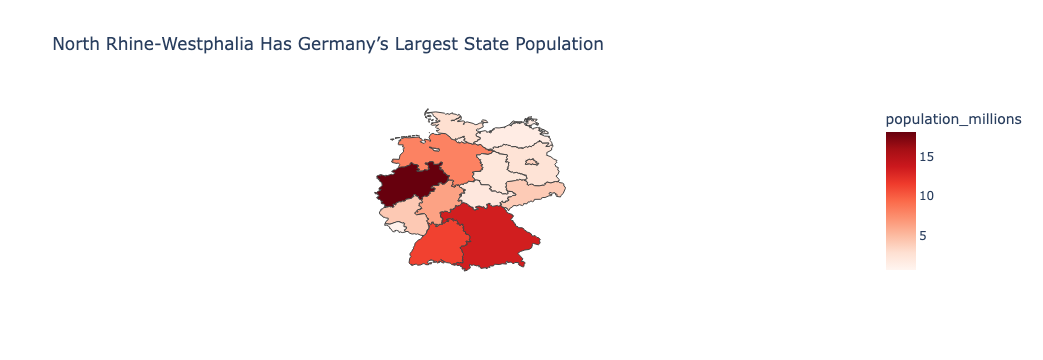

In [5]:
fig = px.choropleth(
    states,
    geojson=germany_geojson,
    locations='state',
    featureidkey='properties.name',
    color='population_millions',
    color_continuous_scale='Reds',
    title='North Rhine-Westphalia Has Germany’s Largest State Population',
    hover_data={'population_millions': ':.1f'}
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.show()